# 00 — Exploratory Data Analysis & Train/Test Split
## MR Localization via Radio Fingerprinting

**Purpose.** This notebook constitutes Module 0 (M0) of the localization pipeline. It characterizes the two input datasets — `measurement_data.csv` (ray-tracing output) and `gcell_conf.csv` (cell configuration) — derives empirically grounded design decisions for the downstream modules, and performs the **train/test split** that partitions data into `measurement_data_train.parquet` (used by M1 to build the fingerprint DB) and `measurement_data_test.parquet` (used by M2 as query events for evaluation).

**Notebook structure.**

| Section | Topic |
|---|---|
| §1 | Load & Overview |
| §2 | Data Quality Audit |
| §3 | RSRP Signal-Strength Distribution |
| §4 | Spatial Structure of the Study Area |
| §5 | Network Topology |
| §6 | Cell Visibility & Fingerprint Sparsity |
| §7 | Feature Discriminability via PCA |
| §8 | Key Findings & Design Decisions |
| §9 | Train/Test Split & Save Artifacts |

**Outputs.**

| File | Description |
|---|---|
| `data/processed/measurement_data_train.parquet` | Training UE records — used by M1 to build `fp_db` |
| `data/processed/measurement_data_test.parquet` | Test UE records — used by M2 as evaluation query events |
| `results/eda_*.png` | EDA figures |

## 0. Setup

In [18]:
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupShuffleSplit
from scipy.stats import spearmanr

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', '{:.3f}'.format)
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)

MEASUREMENT_DATA_PATH = '../data/raw/measurement_data.csv'
GCELL_CONF_PATH       = '../data/raw/gcell_conf.csv'
PROCESSED_DIR         = '../data/processed'

os.makedirs('../results', exist_ok=True)
os.makedirs(PROCESSED_DIR, exist_ok=True)

print('Libraries loaded.')

Libraries loaded.


## 1. Load & Overview

Load the two input files and confirm their basic structure before any analysis.

| File | Description |
|---|---|
| `measurement_data.csv` | Long-format ray-tracing output. Each row is one `(UE position, cell, RSRP)` triple. |
| `gcell_conf.csv` | Static cell configuration: one row per LTE cell with antenna coordinates, height, azimuth, and digital tilt. |

In [19]:
measurement_df = pd.read_csv(MEASUREMENT_DATA_PATH)
gcell_conf_df  = pd.read_csv(GCELL_CONF_PATH)

print(f'measurement_data : {measurement_df.shape[0]:,} rows × {measurement_df.shape[1]} columns')
print(f'gcell_conf       : {gcell_conf_df.shape[0]} rows × {gcell_conf_df.shape[1]} columns')

measurement_data : 41,481 rows × 7 columns
gcell_conf       : 26 rows × 8 columns


In [20]:
print('=== measurement_data ===')
measurement_df.info()
measurement_df.head(5)

=== measurement_data ===
<class 'pandas.DataFrame'>
RangeIndex: 41481 entries, 0 to 41480
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   ue_id      41481 non-null  str    
 1   sim_x      41481 non-null  float64
 2   sim_y      41481 non-null  float64
 3   date       41481 non-null  str    
 4   rsrp       41481 non-null  float64
 5   gcell_id   41481 non-null  str    
 6   ue_height  41481 non-null  float64
dtypes: float64(4), str(3)
memory usage: 6.0 MB


,ue_id,sim_x,sim_y,date,rsrp,gcell_id,ue_height
0,e3d3e5fb61d454ce8fc44cc8b94b0723,-126.868,-390.476,2026-03-18 19:38:15.729000+00:00,-82.000,296382a9c48359978b4c4433a81194a1,0.500
1,e3d3e5fb61d454ce8fc44cc8b94b0723,-110.056,-343.944,2026-03-18 19:38:15.729000+00:00,-82.000,296382a9c48359978b4c4433a81194a1,0.500
2,e3d3e5fb61d454ce8fc44cc8b94b0723,-66.343,-293.833,2026-03-18 19:38:15.729000+00:00,-82.000,296382a9c48359978b4c4433a81194a1,0.500
3,e3d3e5fb61d454ce8fc44cc8b94b0723,-79.793,-309.941,2026-03-18 19:38:15.729000+00:00,-82.000,296382a9c48359978b4c4433a81194a1,0.500
4,e3d3e5fb61d454ce8fc44cc8b94b0723,-103.331,-334.996,2026-03-18 19:38:15.729000+00:00,-82.000,296382a9c48359978b4c4433a81194a1,0.500


In [21]:
print('=== gcell_conf ===')
gcell_conf_df.info()
gcell_conf_df.head(5)

=== gcell_conf ===
<class 'pandas.DataFrame'>
RangeIndex: 26 entries, 0 to 25
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   gcell_id        26 non-null     str    
 1   gnodeb_id       26 non-null     str    
 2   sim_x           26 non-null     float64
 3   sim_y           26 non-null     float64
 4   antenna_height  26 non-null     float64
 5   sync_date       26 non-null     str    
 6   digital_tilt    26 non-null     float64
 7   azimuth         26 non-null     float64
dtypes: float64(5), str(3)
memory usage: 3.6 KB


,gcell_id,gnodeb_id,sim_x,sim_y,antenna_height,sync_date,digital_tilt,azimuth
0,31c961ef3add553789472d3c8f142b8c,708fe16de58354bcb76c0442a910cab3,-705.664,-423.328,15.000,2026-04-01,6.000,46.499
1,445260e4d9e85a409ff8637aed4a0fb0,708fe16de58354bcb76c0442a910cab3,-705.664,-423.328,15.000,2026-04-01,6.000,321.136
2,f54c4e3c4b8c557fa19dc11b5cf7e1de,4b9330432d7c5003a0e8ed3166c7e289,-735.414,379.031,15.000,2026-04-01,6.000,43.922
3,b01a463a209e553b80729fa497d38f7e,4b9330432d7c5003a0e8ed3166c7e289,-735.414,379.031,15.000,2026-04-01,6.000,84.641
4,bdb144be0d005f64a1735f9b7731ee22,a01de0d8dc865dc2b525d3be3afb3b6f,-144.664,163.835,30.000,2026-04-01,6.000,55.409


## 2. Data Quality Audit

Systematic integrity check: filter simulation artefacts, validate RSRP range (3GPP TS 36.133: −140 to −44 dBm), and confirm referential integrity between the two datasets.

In [22]:
# 2.1  Simulation artefact removal (rsrp == 0)
artifact_mask      = measurement_df['rsrp'] == 0
print(f'Records with RSRP = 0 (simulation artefact) : {artifact_mask.sum()}')
measurement_df_clean = measurement_df[~artifact_mask].copy()
print(f'Records retained after filtering             : {len(measurement_df_clean):,}')

# 2.2  RSRP value-range validation
rsrp_min = measurement_df_clean['rsrp'].min()
rsrp_max = measurement_df_clean['rsrp'].max()
print(f'\nRSRP range   : [{rsrp_min:.1f}, {rsrp_max:.1f}] dBm')
print(f'RSRP >= -50 dBm (near-field)          : {(measurement_df_clean["rsrp"] >= -50).sum()}')
print(f'RSRP <= -110 dBm (near sensitivity)   : {(measurement_df_clean["rsrp"] <= -110).sum()}')

# 2.3  Referential integrity
meas_cells = set(measurement_df_clean['gcell_id'].unique())
conf_cells  = set(gcell_conf_df['gcell_id'].unique())
print(f'\nUnique cells in measurement_data   : {len(meas_cells)}')
print(f'Unique cells in gcell_conf          : {len(conf_cells)}')
print(f'Orphan IDs in measurements          : {len(meas_cells - conf_cells)}  <- must be 0')

# 2.4  Dataset scope summary
n_unique_pos = measurement_df_clean.groupby(['sim_x', 'sim_y']).ngroups
n_unique_ue  = measurement_df_clean['ue_id'].nunique()
n_unique_ev  = measurement_df_clean.groupby(['ue_id', 'date']).ngroups
print(f'\nUnique (sim_x, sim_y) positions : {n_unique_pos:,}')
print(f'Unique UE identifiers           : {n_unique_ue:,}')
print(f'Unique (ue_id, date) events     : {n_unique_ev:,}')
print(f'Avg records per position        : {len(measurement_df_clean)/n_unique_pos:.1f}')

Records with RSRP = 0 (simulation artefact) : 6
Records retained after filtering             : 41,475

RSRP range   : [-117.0, -42.0] dBm
RSRP >= -50 dBm (near-field)          : 17
RSRP <= -110 dBm (near sensitivity)   : 447

Unique cells in measurement_data   : 26
Unique cells in gcell_conf          : 26
Orphan IDs in measurements          : 0  <- must be 0

Unique (sim_x, sim_y) positions : 8,403
Unique UE identifiers           : 1,490
Unique (ue_id, date) events     : 7,919
Avg records per position        : 4.9


## 3. RSRP Signal-Strength Distribution

The marginal distribution of each cell's RSRP across all reference positions governs its discriminative contribution. We examine the aggregate distribution (histogram + KDE + CDF) and per-cell statistics (boxplots).

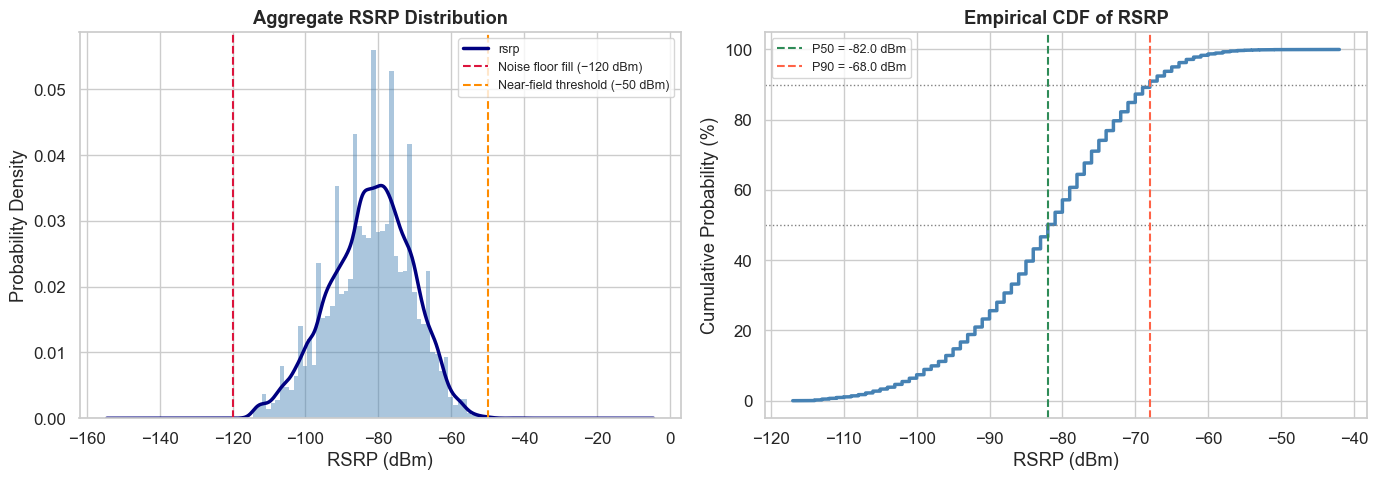

Descriptive statistics:
count   41475.000
mean      -82.193
std        11.290
min      -117.000
25%       -90.000
50%       -82.000
75%       -74.000
max       -42.000

Dynamic range: 75.0 dB


In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
rsrp_vals = measurement_df_clean['rsrp']

# Histogram + KDE
ax = axes[0]
ax.hist(rsrp_vals, bins=60, density=True, alpha=0.45, color='steelblue', edgecolor='none')
rsrp_vals.plot.kde(ax=ax, color='navy', linewidth=2.5)
ax.axvline(-120, color='crimson',    linestyle='--', linewidth=1.5, label='Noise floor fill (−120 dBm)')
ax.axvline(-50,  color='darkorange', linestyle='--', linewidth=1.5, label='Near-field threshold (−50 dBm)')
ax.set_xlabel('RSRP (dBm)')
ax.set_ylabel('Probability Density')
ax.set_title('Aggregate RSRP Distribution', fontweight='bold')
ax.legend(fontsize=9)

# Empirical CDF
ax2 = axes[1]
sorted_rsrp = np.sort(rsrp_vals)
cdf = np.arange(1, len(sorted_rsrp) + 1) / len(sorted_rsrp)
ax2.plot(sorted_rsrp, cdf * 100, color='steelblue', linewidth=2.5)
for pct, col in [(50, 'seagreen'), (90, 'tomato')]:
    val = np.percentile(sorted_rsrp, pct)
    ax2.axhline(pct, color='gray', linestyle=':', linewidth=1)
    ax2.axvline(val, color=col, linestyle='--', linewidth=1.5, label=f'P{pct} = {val:.1f} dBm')
ax2.set_xlabel('RSRP (dBm)')
ax2.set_ylabel('Cumulative Probability (%)')
ax2.set_title('Empirical CDF of RSRP', fontweight='bold')
ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig('../results/eda_rsrp_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print('Descriptive statistics:')
print(measurement_df_clean['rsrp'].describe().to_string())
print(f'\nDynamic range: {rsrp_max - rsrp_min:.1f} dB')

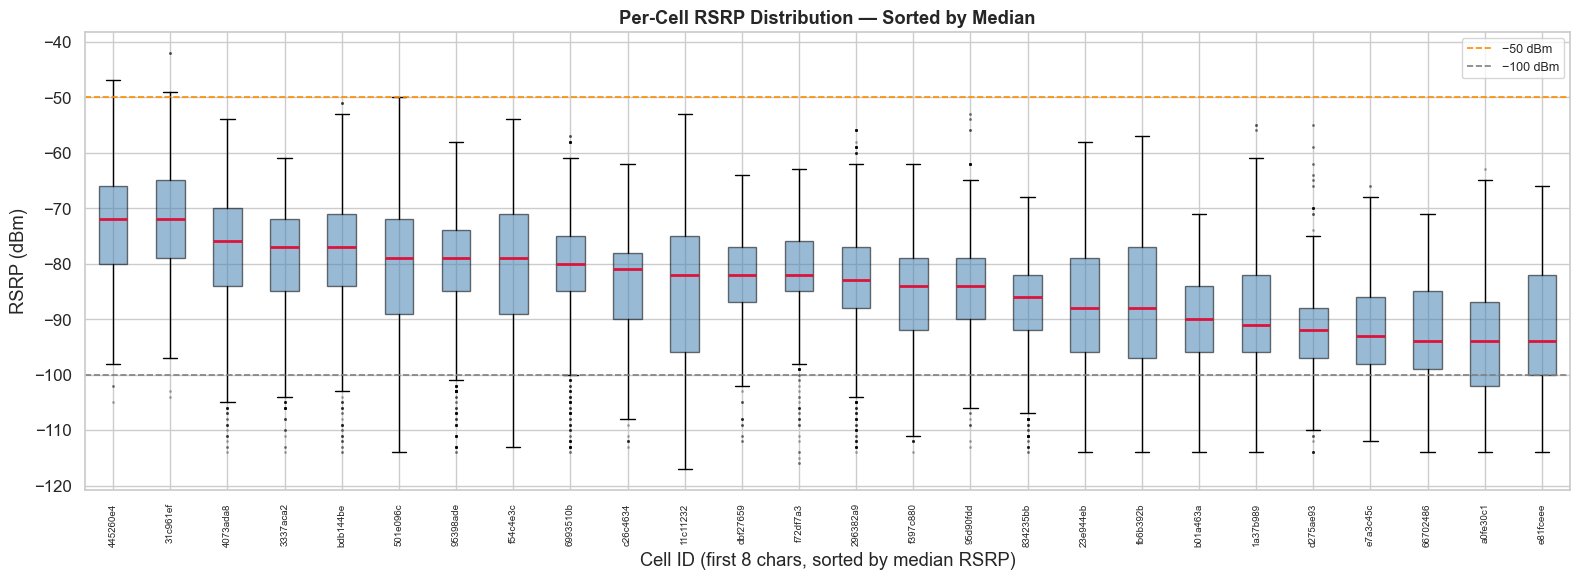

Inter-cell median spread : 22.0 dB
Mean within-cell IQR     : 13.5 dB


In [24]:
cell_medians  = measurement_df_clean.groupby('gcell_id')['rsrp'].median().sort_values(ascending=False)
ordered_cells = cell_medians.index.tolist()
data_by_cell  = [measurement_df_clean.loc[measurement_df_clean['gcell_id'] == c, 'rsrp'].values
                 for c in ordered_cells]
short_labels  = [c[:8] for c in ordered_cells]

fig, ax = plt.subplots(figsize=(16, 6))
bp = ax.boxplot(data_by_cell, patch_artist=True, notch=False,
                medianprops=dict(color='crimson', linewidth=2),
                flierprops=dict(marker='.', markersize=2, alpha=0.3, color='gray'))
for patch in bp['boxes']:
    patch.set_facecolor('steelblue')
    patch.set_alpha(0.55)
ax.set_xticks(range(1, len(ordered_cells) + 1))
ax.set_xticklabels(short_labels, rotation=90, fontsize=7)
ax.set_xlabel('Cell ID (first 8 chars, sorted by median RSRP)')
ax.set_ylabel('RSRP (dBm)')
ax.set_title('Per-Cell RSRP Distribution — Sorted by Median', fontweight='bold')
ax.axhline(-50,  color='darkorange', linestyle='--', linewidth=1.2, label='−50 dBm')
ax.axhline(-100, color='gray',       linestyle='--', linewidth=1.2, label='−100 dBm')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('../results/eda_rsrp_per_cell.png', dpi=150, bbox_inches='tight')
plt.show()

cell_rsrp = measurement_df_clean.groupby('gcell_id')['rsrp']
cell_iqr  = cell_rsrp.quantile(0.75) - cell_rsrp.quantile(0.25)
print(f'Inter-cell median spread : {cell_medians.iloc[0] - cell_medians.iloc[-1]:.1f} dB')
print(f'Mean within-cell IQR     : {cell_iqr.mean():.1f} dB')

## 4. Spatial Structure of the Study Area

The density and regularity of the reference measurement grid bound the spatial resolution of the fingerprint database. WKNN accuracy is limited by the average inter-point spacing: if the K nearest fingerprints in feature space span a 50 m radius, the weighted centroid still carries a ~50 m baseline error.

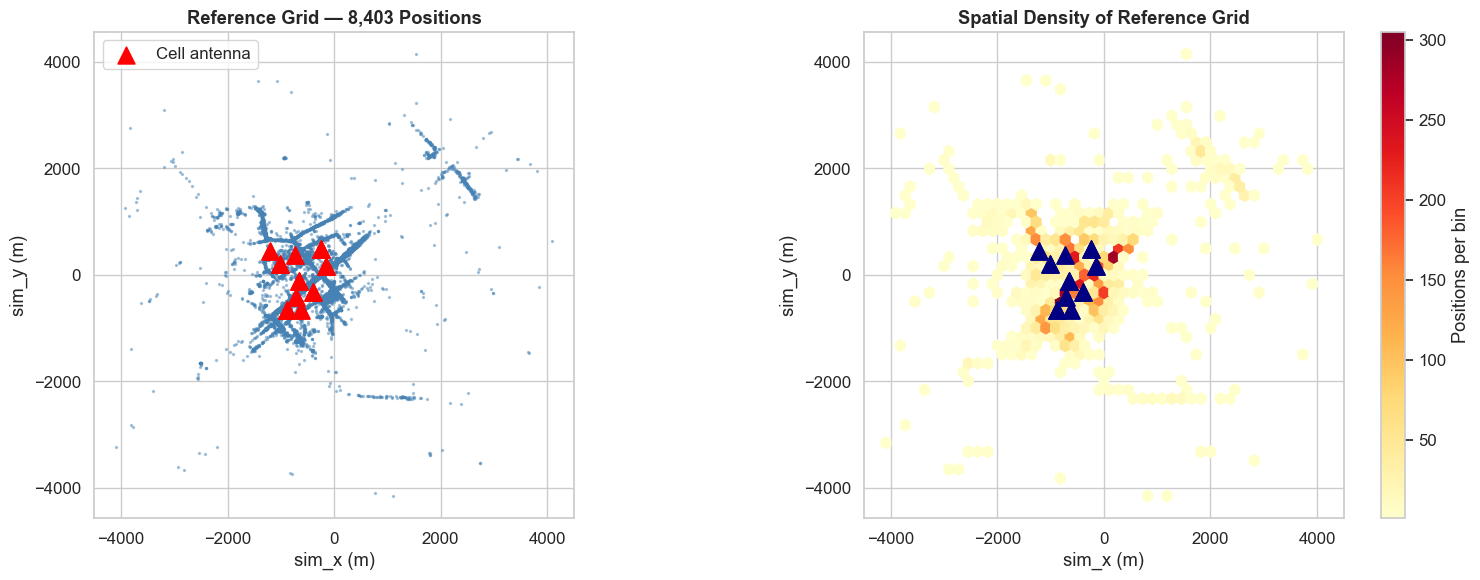

Study area extent        : 8191 m (E-W) x 8297 m (N-S)
Bounding-box area        : 67.963 km2
Total reference positions: 8,403
Avg inter-point spacing  : ~89.9 m
sim_x range: [-4095.1, 4096.2] m
sim_y range: [-4148.8, 4148.2] m


In [25]:
unique_pos = measurement_df_clean.drop_duplicates(subset=['sim_x', 'sim_y'])[['sim_x', 'sim_y']].copy()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
ax.scatter(unique_pos['sim_x'], unique_pos['sim_y'], s=2, alpha=0.4, color='steelblue', rasterized=True)
ax.scatter(gcell_conf_df['sim_x'], gcell_conf_df['sim_y'], s=150, color='red', marker='^', zorder=5, label='Cell antenna')
ax.set_xlabel('sim_x (m)')
ax.set_ylabel('sim_y (m)')
ax.set_title(f'Reference Grid — {len(unique_pos):,} Positions', fontweight='bold')
ax.legend()
ax.set_aspect('equal')

ax2 = axes[1]
hb = ax2.hexbin(unique_pos['sim_x'], unique_pos['sim_y'], gridsize=45, cmap='YlOrRd', mincnt=1)
plt.colorbar(hb, ax=ax2, label='Positions per bin')
ax2.scatter(gcell_conf_df['sim_x'], gcell_conf_df['sim_y'], s=150, color='navy', marker='^', zorder=5)
ax2.set_xlabel('sim_x (m)')
ax2.set_ylabel('sim_y (m)')
ax2.set_title('Spatial Density of Reference Grid', fontweight='bold')
ax2.set_aspect('equal')

plt.tight_layout()
plt.savefig('../results/eda_spatial_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

x_range     = unique_pos['sim_x'].max() - unique_pos['sim_x'].min()
y_range     = unique_pos['sim_y'].max() - unique_pos['sim_y'].min()
area_km2    = (x_range * y_range) / 1e6
avg_spacing = np.sqrt(area_km2 * 1e6 / len(unique_pos))
print(f'Study area extent        : {x_range:.0f} m (E-W) x {y_range:.0f} m (N-S)')
print(f'Bounding-box area        : {area_km2:.3f} km2')
print(f'Total reference positions: {len(unique_pos):,}')
print(f'Avg inter-point spacing  : ~{avg_spacing:.1f} m')
print(f'sim_x range: [{unique_pos["sim_x"].min():.1f}, {unique_pos["sim_x"].max():.1f}] m')
print(f'sim_y range: [{unique_pos["sim_y"].min():.1f}, {unique_pos["sim_y"].max():.1f}] m')

## 5. Network Topology

The spatial configuration of gNodeBs and sector azimuths governs the RSRP field structure. Cells with well-distributed boresight directions produce the most spatially varied — and therefore most discriminative — RSRP gradients.

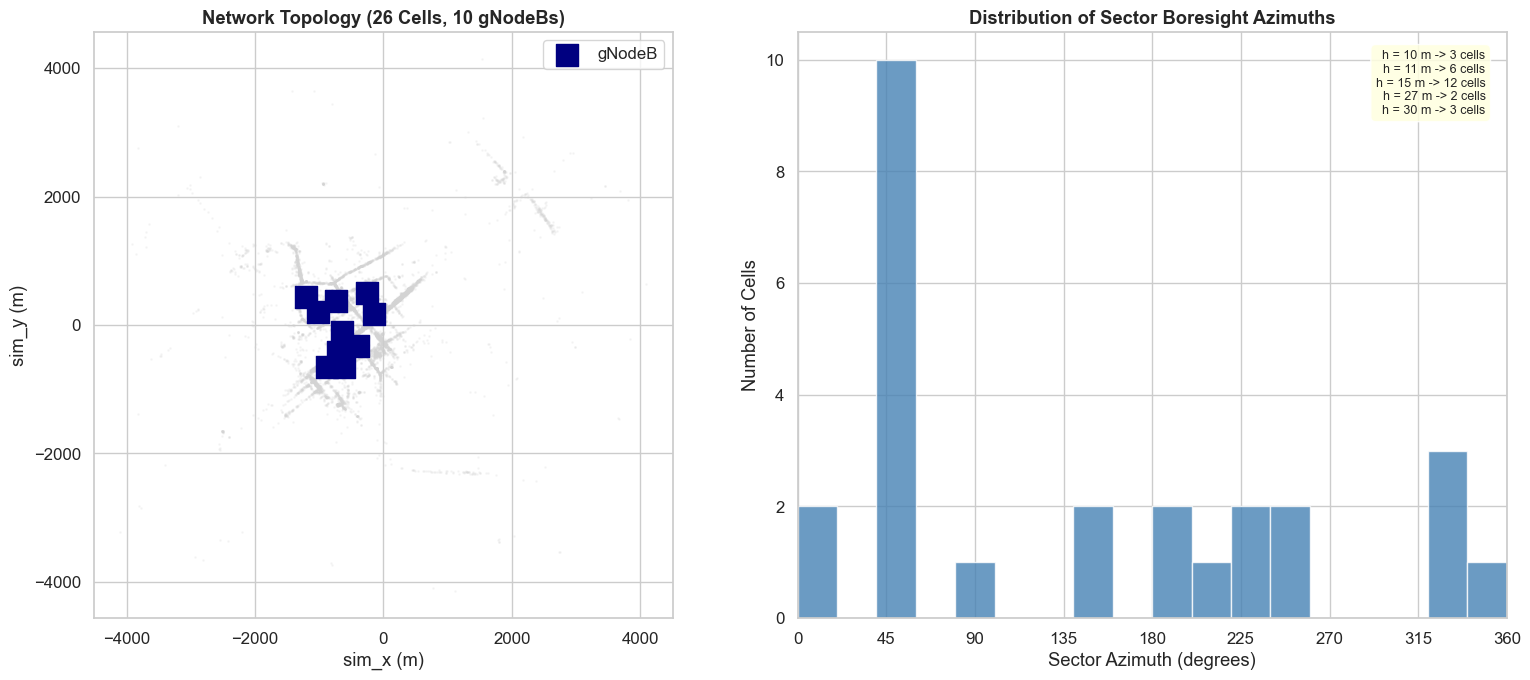

Per-gNodeB summary:
  gnodeb_id  n_cells  h_ant  mean_tilt
1b1f14b6...        2 27.000      6.000
4b933043...        2 15.000      6.000
708fe16d...        2 15.000      6.000
a01de0d8...        3 30.000      6.667
a4a6ffcd...        3 10.000      6.667
a7fba16a...        2 15.000      7.000
bbb56a4a...        3 11.000      7.000
db390f71...        3 15.000      6.000
e42d434f...        3 11.000      6.000
fe3ea5bf...        3 15.000      6.000


In [26]:
def az_to_arrow(az_deg, length=90):
    rad = np.radians(90.0 - az_deg)
    return np.cos(rad) * length, np.sin(rad) * length

gnodeb_pos  = gcell_conf_df.groupby('gnodeb_id')[['sim_x', 'sim_y']].mean()
cell_colors = plt.get_cmap('tab10')(np.linspace(0, 0.9, len(gcell_conf_df)))

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

ax = axes[0]
ax.scatter(unique_pos['sim_x'], unique_pos['sim_y'], s=1, alpha=0.15, color='lightgray', rasterized=True, zorder=0)
ax.scatter(gnodeb_pos['sim_x'], gnodeb_pos['sim_y'], s=250, color='navy', marker='s', zorder=5, label='gNodeB')
for i, (_, row) in enumerate(gcell_conf_df.iterrows()):
    dx, dy = az_to_arrow(row['azimuth'], length=90)
    ax.annotate('', xy=(row['sim_x'] + dx, row['sim_y'] + dy), xytext=(row['sim_x'], row['sim_y']),
                arrowprops=dict(arrowstyle='->', color=cell_colors[i], lw=2.2))
ax.set_xlabel('sim_x (m)')
ax.set_ylabel('sim_y (m)')
ax.set_title(f'Network Topology ({len(gcell_conf_df)} Cells, {len(gnodeb_pos)} gNodeBs)', fontweight='bold')
ax.legend()
ax.set_aspect('equal')

ax2 = axes[1]
ax2.hist(gcell_conf_df['azimuth'], bins=18, range=(0, 360), color='steelblue', edgecolor='white', alpha=0.8)
ax2.set_xlabel('Sector Azimuth (degrees)')
ax2.set_ylabel('Number of Cells')
ax2.set_xlim(0, 360)
ax2.set_xticks(range(0, 361, 45))
ax2.set_title('Distribution of Sector Boresight Azimuths', fontweight='bold')
height_info = gcell_conf_df.groupby('antenna_height')['gcell_id'].count()
info_str = '\n'.join([f'h = {h:.0f} m -> {n} cells' for h, n in height_info.items()])
ax2.text(0.97, 0.97, info_str, transform=ax2.transAxes, fontsize=9, va='top', ha='right',
         bbox=dict(boxstyle='round,pad=0.4', facecolor='lightyellow', alpha=0.85))

plt.tight_layout()
plt.savefig('../results/eda_network_topology.png', dpi=150, bbox_inches='tight')
plt.show()

gnodeb_summary = (gcell_conf_df.groupby('gnodeb_id')
                  .agg(n_cells=('gcell_id', 'count'), h_ant=('antenna_height', 'first'),
                       mean_tilt=('digital_tilt', 'mean'))
                  .reset_index())
gnodeb_summary['gnodeb_id'] = gnodeb_summary['gnodeb_id'].str[:8] + '...'
print('Per-gNodeB summary:')
print(gnodeb_summary.to_string(index=False))

## 6. Cell Visibility & Fingerprint Sparsity

**Cell visibility** — the number of distinct cells simultaneously observable from a given position — is the primary determinant of fingerprint uniqueness. With few observed cells, Euclidean distance in the full 26-D space is dominated by the noise-floor fill dimensions rather than signal-bearing ones, reducing discriminative power.

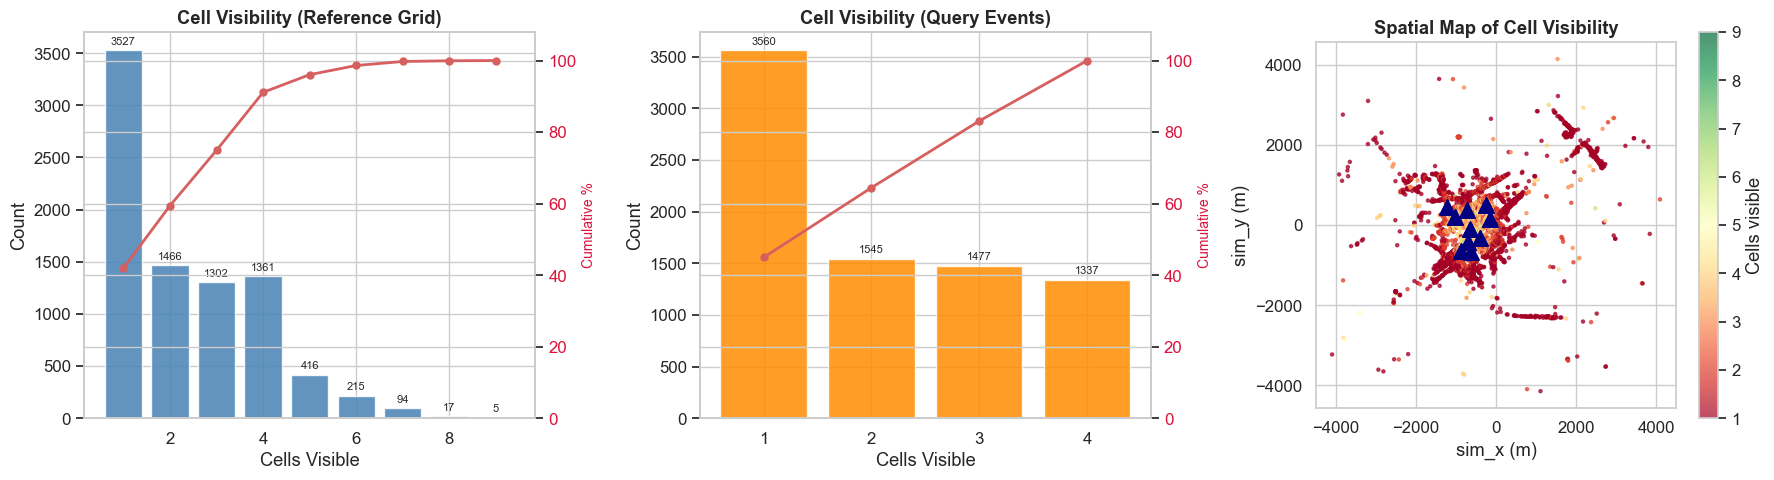

Cell visibility at reference positions:
count   8403.000
mean       2.382
std        1.521
min        1.000
25%        1.000
50%        2.000
75%        4.000
max        9.000

Positions with 1 cell  : 3,527 (42.0%)
Positions with 4+ cells: 2,108 (25.1%)


In [27]:
cells_per_pos = (measurement_df_clean.groupby(['sim_x', 'sim_y'])['gcell_id']
                 .nunique().reset_index(name='n_cells'))
cells_per_query = (measurement_df_clean.groupby(['ue_id', 'date'])['gcell_id']
                   .nunique().reset_index(name='n_cells'))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, data, title, color in [
    (axes[0], cells_per_pos,   'Cell Visibility (Reference Grid)', 'steelblue'),
    (axes[1], cells_per_query, 'Cell Visibility (Query Events)',   'darkorange'),
]:
    counts = data['n_cells'].value_counts().sort_index()
    bars   = ax.bar(counts.index, counts.values, color=color, edgecolor='white', alpha=0.85)
    ax.bar_label(bars, fmt='%d', fontsize=8, padding=3)
    cdf    = counts.cumsum() / counts.sum()
    cdf_pct: np.ndarray = cdf.to_numpy(dtype=float) * 100
    ax_r   = ax.twinx()
    ax_r.plot(counts.index, cdf_pct, 'r-o', lw=2, ms=5)
    ax_r.set_ylabel('Cumulative %', color='crimson', fontsize=10)
    ax_r.tick_params(axis='y', labelcolor='crimson')
    ax_r.set_ylim(0, 108)
    ax.set_xlabel('Cells Visible')
    ax.set_ylabel('Count')
    ax.set_title(title, fontweight='bold')

ax3 = axes[2]
sc  = ax3.scatter(cells_per_pos['sim_x'], cells_per_pos['sim_y'],
                  c=cells_per_pos['n_cells'], cmap='RdYlGn',
                  s=5, alpha=0.7, vmin=1, vmax=cells_per_pos['n_cells'].max(), rasterized=True)
plt.colorbar(sc, ax=ax3, label='Cells visible')
ax3.scatter(gcell_conf_df['sim_x'], gcell_conf_df['sim_y'], s=120, color='navy', marker='^', zorder=5)
ax3.set_xlabel('sim_x (m)')
ax3.set_ylabel('sim_y (m)')
ax3.set_title('Spatial Map of Cell Visibility', fontweight='bold')
ax3.set_aspect('equal')

plt.tight_layout()
plt.savefig('../results/eda_cell_visibility.png', dpi=150, bbox_inches='tight')
plt.show()

print('Cell visibility at reference positions:')
print(cells_per_pos['n_cells'].describe().to_string())
print(f'\nPositions with 1 cell  : {(cells_per_pos["n_cells"]==1).sum():,} '
      f'({(cells_per_pos["n_cells"]==1).mean()*100:.1f}%)')
print(f'Positions with 4+ cells: {(cells_per_pos["n_cells"]>=4).sum():,} '
      f'({(cells_per_pos["n_cells"]>=4).mean()*100:.1f}%)')

## 7. Feature Discriminability via PCA

PCA on the fingerprint matrix reveals the **intrinsic dimensionality** of the radio feature space. If PC1/PC2 exhibit smooth spatial gradients correlated with `sim_x`/`sim_y`, the fingerprints are **spatially coherent** — a necessary condition for WKNN to produce accurate estimates.

In [28]:
# Build a temporary fingerprint matrix for PCA (not saved — training split happens in §9)
fp_tmp = (measurement_df_clean
          .groupby(['sim_x', 'sim_y', 'gcell_id'])['rsrp']
          .mean().unstack('gcell_id').reset_index().fillna(-120.0))
cell_cols = [c for c in fp_tmp.columns if c not in ['sim_x', 'sim_y']]
X_fp      = fp_tmp[cell_cols].values
FILL_VAL  = -120.0
print(f'Temporary fingerprint matrix: {X_fp.shape}')

Temporary fingerprint matrix: (8403, 26)


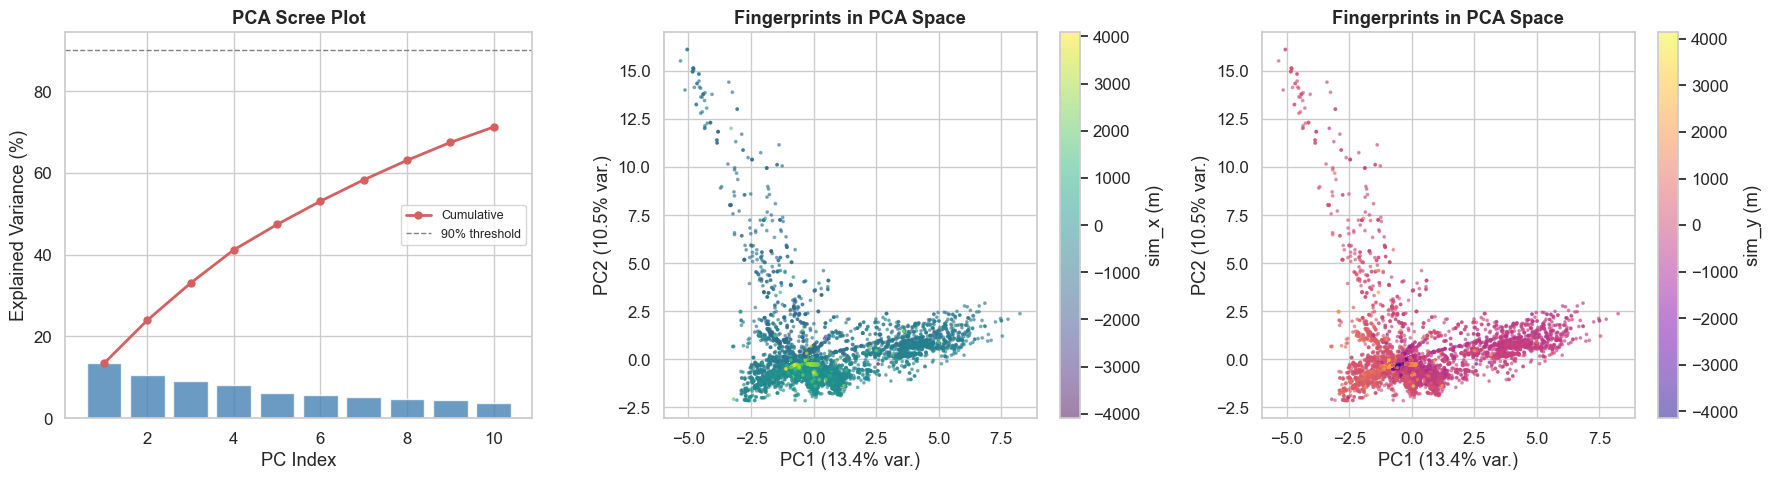

Components for 90% variance: 1
PC1 variance: 13.4%,  PC2: 10.5%,  cumulative: 24.0%

Spatial coherence (Spearman rho):
  PC1: rho(sim_x) = +0.128,  rho(sim_y) = -0.412
  PC2: rho(sim_x) = -0.584,  rho(sim_y) = -0.104
  PC3: rho(sim_x) = +0.209,  rho(sim_y) = +0.411


In [29]:
scaler       = StandardScaler()
X_scaled     = scaler.fit_transform(X_fp)
n_components = min(10, len(cell_cols))
pca          = PCA(n_components=n_components, random_state=42)
X_pca        = pca.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Scree plot
ev, cumev = pca.explained_variance_ratio_ * 100, np.cumsum(pca.explained_variance_ratio_ * 100)
axes[0].bar(range(1, n_components + 1), ev, color='steelblue', alpha=0.8)
axes[0].plot(range(1, n_components + 1), cumev, 'r-o', lw=2, ms=5, label='Cumulative')
axes[0].axhline(90, color='gray', linestyle='--', lw=1, label='90% threshold')
axes[0].set_xlabel('PC Index')
axes[0].set_ylabel('Explained Variance (%)')
axes[0].set_title('PCA Scree Plot', fontweight='bold')
axes[0].legend(fontsize=9)

# PC1 vs PC2 coloured by sim_x / sim_y
for ax, col, label, cmap in [
    (axes[1], fp_tmp['sim_x'].to_numpy(dtype=float), 'sim_x (m)', 'viridis'),
    (axes[2], fp_tmp['sim_y'].to_numpy(dtype=float), 'sim_y (m)', 'plasma'),
]:
    sc = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=col, cmap=cmap, s=3, alpha=0.5, rasterized=True)
    plt.colorbar(sc, ax=ax, label=label)
    ax.set_xlabel(f'PC1 ({ev[0]:.1f}% var.)')
    ax.set_ylabel(f'PC2 ({ev[1]:.1f}% var.)')
    ax.set_title('Fingerprints in PCA Space', fontweight='bold')

plt.tight_layout()
plt.savefig('../results/eda_pca.png', dpi=150, bbox_inches='tight')
plt.show()

n90 = int(np.argmax(cumev >= 90) + 1)
print(f'Components for 90% variance: {n90}')
print(f'PC1 variance: {ev[0]:.1f}%,  PC2: {ev[1]:.1f}%,  cumulative: {cumev[1]:.1f}%')
print('\nSpatial coherence (Spearman rho):')
sim_x_arr = fp_tmp['sim_x'].to_numpy(dtype=float)
sim_y_arr = fp_tmp['sim_y'].to_numpy(dtype=float)
for pc_idx in range(min(3, n_components)):
    r_x, _ = spearmanr(X_pca[:, pc_idx], sim_x_arr)
    r_y, _ = spearmanr(X_pca[:, pc_idx], sim_y_arr)
    print(f'  PC{pc_idx+1}: rho(sim_x) = {r_x:+.3f},  rho(sim_y) = {r_y:+.3f}')

## 8. Key Findings & Design Decisions

| # | Finding | Evidence | Pipeline Decision |
|---|---|---|---|
| 1 | **Simulation artefact** | 6 records with RSRP = 0 | Filter before any processing |
| 2 | **Referential integrity** | All 26 `gcell_id` values match | No orphan-ID handling required |
| 3 | **RSRP dynamic range** | ~75 dB span (−117 to −42 dBm) | Sufficient discriminability; no range compression needed |
| 4 | **High fingerprint sparsity** | ~91% of fingerprint matrix at −120 dBm | Adopt −120 dBm as noise-floor fill |
| 5 | **Cell-visibility heterogeneity** | Significant fraction of positions see only 1 cell | Expect elevated error in low-visibility zones |
| 6 | **Low intrinsic dimensionality** | Few PCs explain ≥90% of variance | Inter-cell redundancy; learned embedding is a natural extension |
| 7 | **Spatial coherence confirmed** | PC1/PC2 exhibit smooth spatial gradients | WKNN in fingerprint space is a valid proxy for geographic proximity |
| 8 | **Train/test split by UE** | 1,490 unique UEs; same UE covers multiple positions | Split by `ue_id` (GroupShuffleSplit) to prevent positional data leakage |

## 9. Train/Test Split & Save Artifacts

Split the cleaned records into train and test sets **by UE** using `GroupShuffleSplit(test_size=0.2, random_state=42)`. Splitting by UE prevents data leakage: if a UE's trajectory appeared in both sets, the model could trivially match test queries to fingerprints from the same geographic cluster.

| Output | Description |
|---|---|
| `measurement_data_train.parquet` | ~80% of UEs — consumed by M1 to build `fp_db` |
| `measurement_data_test.parquet`  | ~20% of UEs — consumed by M2 as evaluation query events |

In [30]:
# Group-shuffle split by ue_id to prevent positional leakage
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(measurement_df_clean, groups=measurement_df_clean['ue_id']))

train_df = measurement_df_clean.iloc[train_idx].copy()
test_df  = measurement_df_clean.iloc[test_idx].copy()

print(f'Train records : {len(train_df):,}  '
      f'({train_df["ue_id"].nunique():,} UEs, '
      f'{train_df.groupby(["sim_x", "sim_y"]).ngroups:,} unique positions)')
print(f'Test  records : {len(test_df):,}  '
      f'({test_df["ue_id"].nunique():,} UEs, '
      f'{test_df.groupby(["sim_x", "sim_y"]).ngroups:,} unique positions)')
print(f'\nUE overlap (must be 0): '
      f'{len(set(train_df["ue_id"]) & set(test_df["ue_id"]))}')

Train records : 34,022  (1,192 UEs, 6,746 unique positions)
Test  records : 7,453  (298 UEs, 1,825 unique positions)

UE overlap (must be 0): 0


In [31]:
train_path = f'{PROCESSED_DIR}/measurement_data_train.parquet'
test_path  = f'{PROCESSED_DIR}/measurement_data_test.parquet'

train_df.to_parquet(train_path, index=False)
test_df.to_parquet(test_path,  index=False)

print(f'Saved measurement_data_train -> {train_path}')
print(f'Saved measurement_data_test  -> {test_path}')

Saved measurement_data_train -> ../data/processed/measurement_data_train.parquet
Saved measurement_data_test  -> ../data/processed/measurement_data_test.parquet
